Signal shape: (650000, 2)
Sampling frequency: 360
Number of annotated beats: 2274


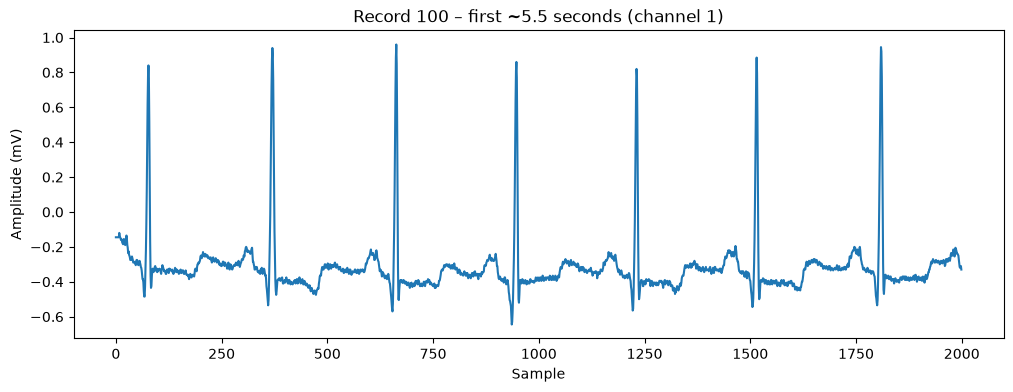

In [1]:
import wfdb
import matplotlib.pyplot as plt

# Load signal and annotations for record 100 (local files)
record = wfdb.rdrecord('../data/mit-bih-arrhythmia-database-1.0.0/100')
annotation = wfdb.rdann('../data/mit-bih-arrhythmia-database-1.0.0/100', 'atr')

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotated beats:", len(annotation.sample))

# Plot the first ~5.5 seconds of channel 1
plt.figure(figsize=(12, 4))
plt.plot(record.p_signal[:2000, 0])
plt.title('Record 100 – first ~5.5 seconds (channel 1)')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

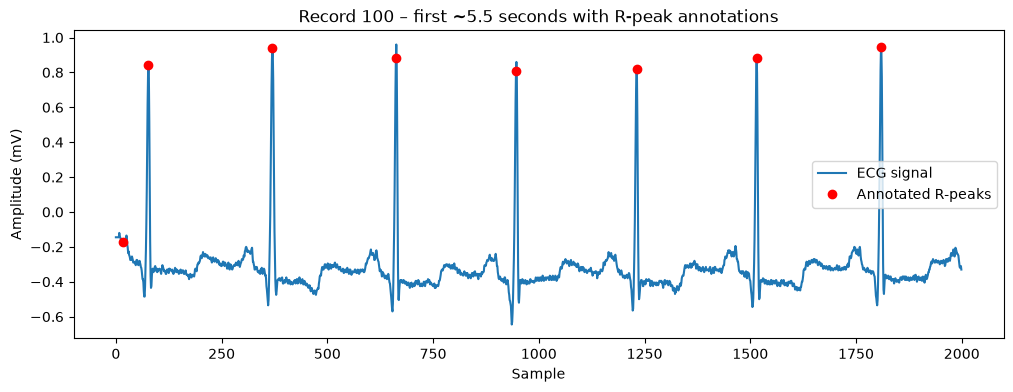

Beat types found in this range: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [2]:
import numpy as np

# We only plotted the first 2000 samples earlier, so we need to find
# which annotated beats fall within that same range
plot_range = 2000
beats_in_range = annotation.sample[annotation.sample < plot_range]

# Re-plot the signal, then overlay markers at each R-peak position
plt.figure(figsize=(12, 4))
plt.plot(record.p_signal[:plot_range, 0], label='ECG signal')
plt.plot(beats_in_range, record.p_signal[beats_in_range, 0], 
          'ro', label='Annotated R-peaks')
plt.title('Record 100 – first ~5.5 seconds with R-peak annotations')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

print("Beat types found in this range:", 
      [annotation.symbol[i] for i in range(len(annotation.sample)) 
       if annotation.sample[i] < plot_range])

Beat type: N, R-peak at sample: 253


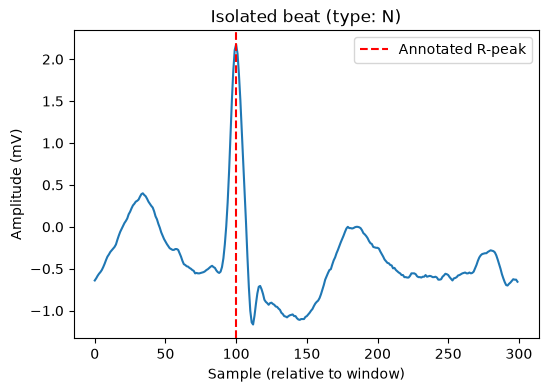

In [13]:
# Pick one annotated N-type beat to isolate (skip the first '+' rhythm marker)
# We use the third annotation, which should be a real 'N' beat
beat_index = 2
r_peak_position = annotation.sample[beat_index]
beat_type = annotation.symbol[beat_index]

print(f"Beat type: {beat_type}, R-peak at sample: {r_peak_position}")

# Define a window around the R-peak: samples before and after
samples_before = 100
samples_after = 200

start = r_peak_position - samples_before
end = r_peak_position + samples_after

# Extract the isolated beat window from channel 1
single_beat = record.p_signal[start:end, 0]

# Plot the isolated beat
plt.figure(figsize=(6, 4))
plt.plot(single_beat)
plt.axvline(x=samples_before, color='red', linestyle='--', label='Annotated R-peak')
plt.title(f'Isolated beat (type: {beat_type})')
plt.xlabel('Sample (relative to window)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

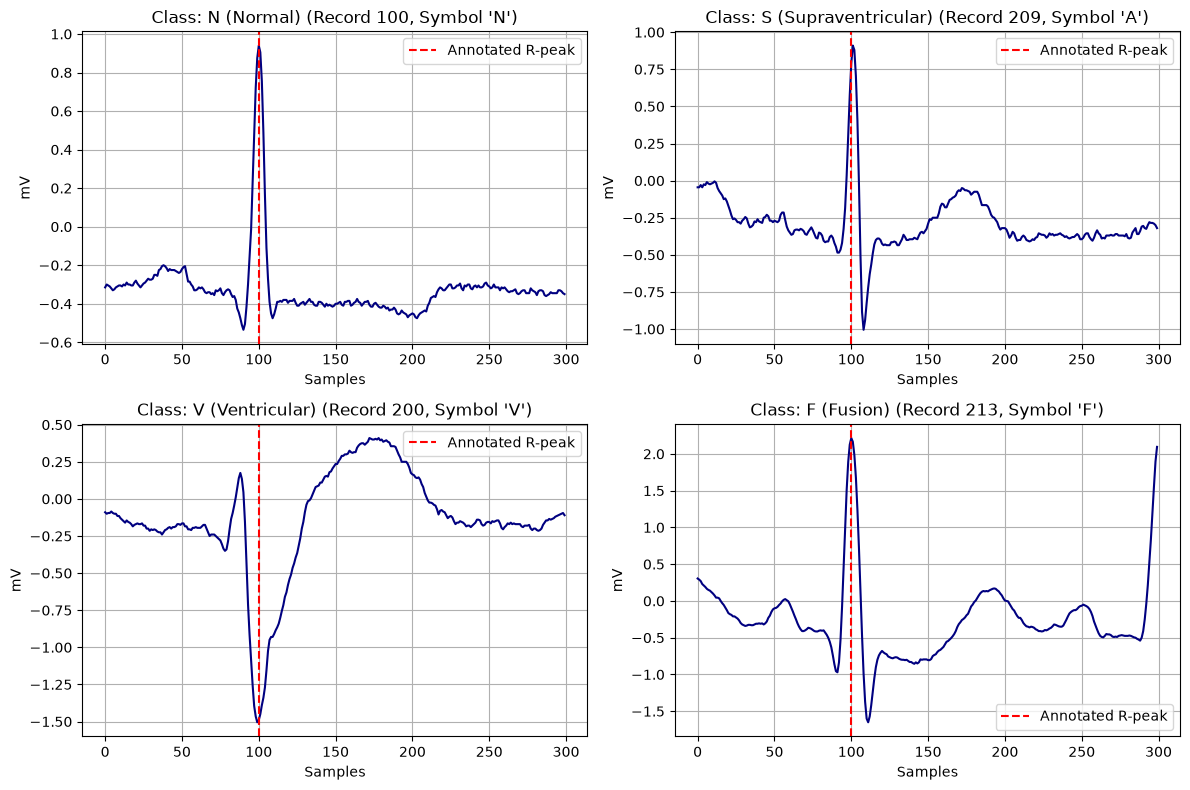

In [21]:
import wfdb
import matplotlib.pyplot as plt

# Mapping: Which record are we searching in for each symbol/class?
# We are searching for the original database symbols: 'N', 'A' (S-class), 'V', and 'F'
targets = {
    'N (Normal)': {'record': '100', 'symbol': 'N'},
    'S (Supraventricular)': {'record': '209', 'symbol': 'A'},
    'V (Ventricular)': {'record': '200', 'symbol': 'V'},
    'F (Fusion)': {'record': '213', 'symbol': 'F'}
}

# Window size (100 samples before R-peak, 200 samples after)
before, after = 100, 200

# Create a figure with 4 subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (class_label, info) in enumerate(targets.items()):
    rec_id = info['record']
    sym = info['symbol']
    
    # Read the selected record and its annotations
    rec = wfdb.rdrecord(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}')
    ann = wfdb.rdann(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}', 'atr')
    
    # Find the first index where the annotation matches our target symbol
    # (Skip early samples to avoid initial transient artifacts)
    beat_idx = None
    for idx, s in enumerate(ann.symbol):
        if s == sym and ann.sample[idx] > before:
            beat_idx = idx
            break
            
    if beat_idx is not None:
        r_pos = ann.sample[beat_idx]
        beat_signal = rec.p_signal[r_pos - before : r_pos + after, 0]
        
        # Plot in the corresponding subplot
        axes[i].plot(beat_signal, color='navy')
        axes[i].axvline(x=before, color='red', linestyle='--', label='Annotated R-peak')
        axes[i].set_title(f"Class: {class_label} (Record {rec_id}, Symbol '{sym}')")
        axes[i].set_xlabel("Samples")
        axes[i].set_ylabel("mV")
        axes[i].grid(True)
        axes[i].legend()

plt.tight_layout()
plt.show()

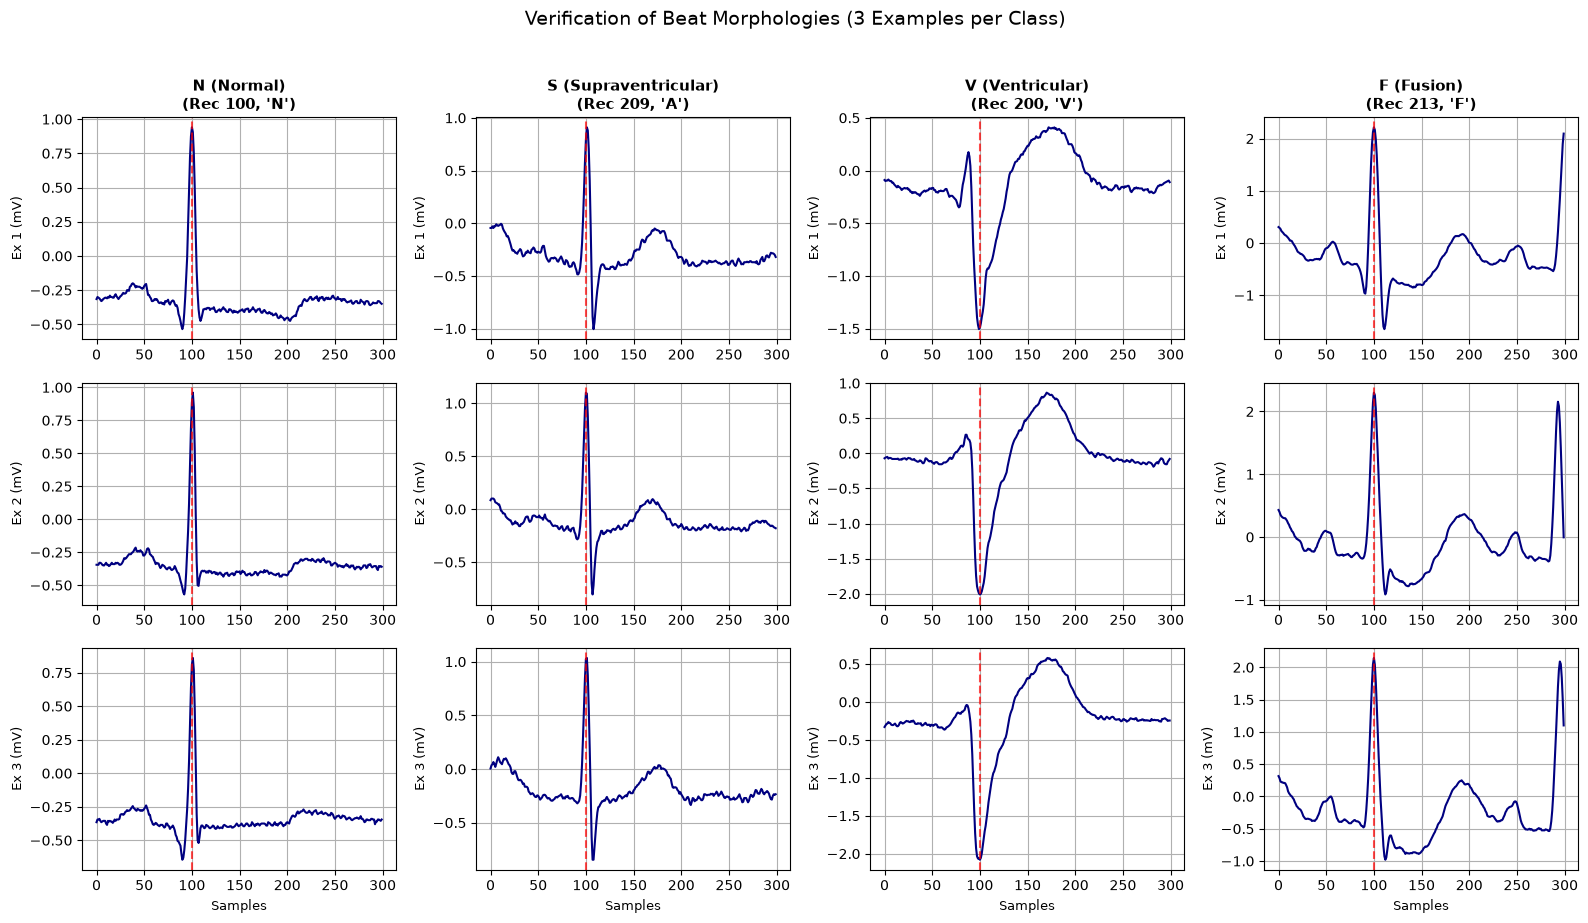

In [22]:
import wfdb
import matplotlib.pyplot as plt

# Define the source record and target symbol for each class
class_configs = {
    'N (Normal)': {'record': '100', 'symbol': 'N'},
    'S (Supraventricular)': {'record': '209', 'symbol': 'A'},
    'V (Ventricular)': {'record': '200', 'symbol': 'V'},
    'F (Fusion)': {'record': '213', 'symbol': 'F'}
}

# Window size (100 samples before annotated R-peak, 200 samples after)
before, after = 100, 200

# Create a 3x4 grid (3 examples per class across 4 target classes)
fig, axes = plt.subplots(3, 4, figsize=(16, 9))

for col_idx, (class_name, config) in enumerate(class_configs.items()):
    rec_id = config['record']
    sym = config['symbol']
    
    # Read record signal and annotations
    rec = wfdb.rdrecord(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}')
    ann = wfdb.rdann(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}', 'atr')
    
    # Locate all annotation indices matching the target symbol
    matching_indices = [
        idx for idx, s in enumerate(ann.symbol) 
        if s == sym and ann.sample[idx] > before
    ]
    
    # Select the first 3 matching beats
    selected_beats = matching_indices[:3]
    
    for row_idx, beat_idx in enumerate(selected_beats):
        ax = axes[row_idx, col_idx]
        r_pos = ann.sample[beat_idx]
        beat_signal = rec.p_signal[r_pos - before : r_pos + after, 0]
        
        # Plot the beat segment and annotated R-peak reference line
        ax.plot(beat_signal, color='navy')
        ax.axvline(x=before, color='red', linestyle='--', alpha=0.7)
        ax.grid(True)
        
        # Set titles and axis labels
        if row_idx == 0:
            ax.set_title(f"{class_name}\n(Rec {rec_id}, '{sym}')", fontsize=11, fontweight='bold')
        ax.set_ylabel(f"Ex {row_idx + 1} (mV)", fontsize=9)
        if row_idx == 2:
            ax.set_xlabel("Samples", fontsize=9)

plt.suptitle("Verification of Beat Morphologies (3 Examples per Class)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

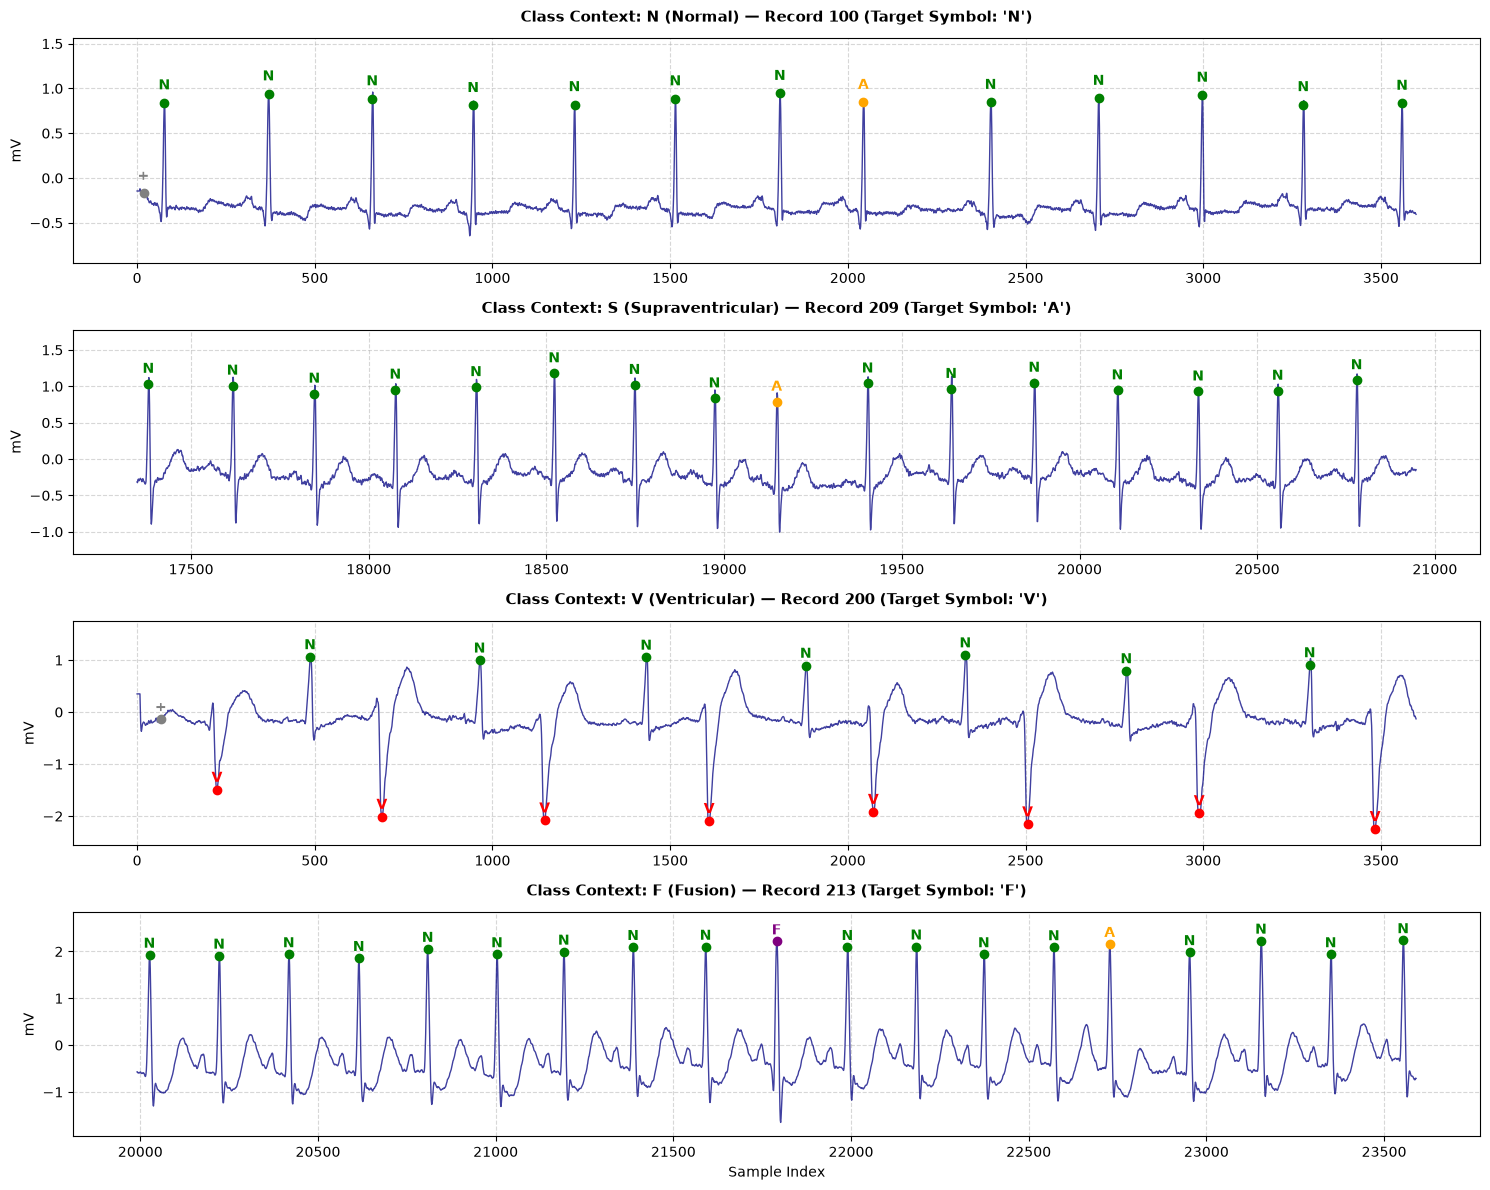

In [23]:
import wfdb
import matplotlib.pyplot as plt

# Define target classes, source records, and specific symbols to locate
targets = [
    {'class': 'N (Normal)', 'record': '100', 'sym': 'N'},
    {'class': 'S (Supraventricular)', 'record': '209', 'sym': 'A'},
    {'class': 'V (Ventricular)', 'record': '200', 'sym': 'V'},
    {'class': 'F (Fusion)', 'record': '213', 'sym': 'F'}
]

# Color mapping for annotation symbols
color_map = {
    'N': 'green',
    'A': 'orange', 'S': 'orange',
    'V': 'red',
    'F': 'purple'
}

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

for i, t in enumerate(targets):
    rec_id = t['record']
    target_sym = t['sym']
    
    # Read record signal and annotations
    rec = wfdb.rdrecord(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}')
    ann = wfdb.rdann(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}', 'atr')
    
    # Locate first occurrence of the target symbol (skip initial 1000 samples)
    match_pos = None
    for idx, s in enumerate(ann.symbol):
        if s == target_sym and ann.sample[idx] > 1000:
            match_pos = ann.sample[idx]
            break
            
    # Define a 10-second window (3600 samples) centered around the match
    if match_pos:
        start_p = max(0, match_pos - 1800)
        end_p = start_p + 3600
    else:
        start_p, end_p = 0, 3600

    signal_segment = rec.p_signal[start_p:end_p, 0]
    x_axis = range(start_p, end_p)
    
    # Plot signal segment
    axes[i].plot(x_axis, signal_segment, color='navy', alpha=0.75, linewidth=1)
    
    # Adjust Y-limits to prevent label overlapping with subplot titles
    y_min, y_max = signal_segment.min(), signal_segment.max()
    axes[i].set_ylim(y_min - 0.3, y_max + 0.6)
    
    # Plot all annotations occurring within the window
    for idx, pos in enumerate(ann.sample):
        if start_p <= pos < end_p:
            sym = ann.symbol[idx]
            y_val = rec.p_signal[pos, 0]
            col = color_map.get(sym, 'gray')
            
            axes[i].plot(pos, y_val, marker='o', color=col, markersize=6)
            axes[i].text(pos, y_val + 0.15, sym, fontsize=10, fontweight='bold', ha='center', color=col)
            
    axes[i].set_title(f"Class Context: {t['class']} — Record {rec_id} (Target Symbol: '{target_sym}')", fontsize=11, fontweight='bold', pad=12)
    axes[i].set_ylabel("mV")
    axes[i].grid(True, linestyle='--', alpha=0.5)

axes[3].set_xlabel("Sample Index")
plt.tight_layout()
plt.show()

Class  Total_Beats  Percentage (%)
    N        90631           89.33
    S         2781            2.74
    V         7236            7.13
    F          803            0.79


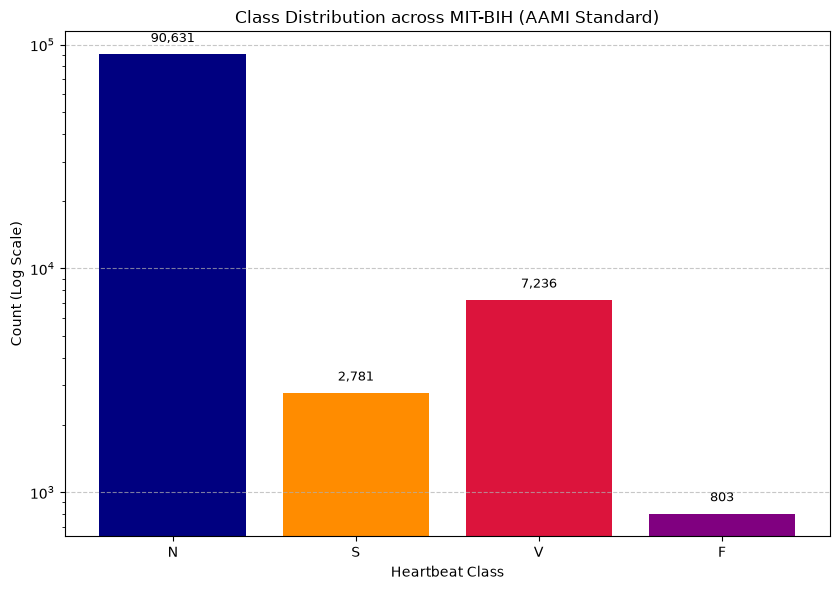

In [ ]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

# All standard records in the MIT-BIH Arrhythmia Database
records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

# AAMI mapping from MIT-BIH native symbols to the 4 target classes
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F'
}

counts = {'N': 0, 'S': 0, 'V': 0, 'F': 0}

# Iterate through all records and aggregate beat counts per mapped class
for rec_id in records:
    ann = wfdb.rdann(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}', 'atr')
    for sym in ann.symbol:
        if sym in aami_map:
            counts[aami_map[sym]] += 1

# Create a pandas DataFrame for structured display
df_counts = pd.DataFrame(list(counts.items()), columns=['Class', 'Total_Beats'])
df_counts['Percentage (%)'] = (df_counts['Total_Beats'] / df_counts['Total_Beats'].sum() * 100).round(2)
print(df_counts.to_string(index=False))

# Plot the distribution
plt.figure(figsize=(8.5, 6))
bars = plt.bar(counts.keys(), counts.values(), color=['navy', 'darkorange', 'crimson', 'purple'])
plt.yscale('log')  # Logarithmic scale applied due to extreme class imbalance
plt.title('Class Distribution across MIT-BIH (AAMI Standard)')
plt.xlabel('Heartbeat Class')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate exact beat counts on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.1, f'{yval:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

record    N    S   V   F  total
   100 2239   33   1   0   2273
   101 1860    3   0   0   1863
   102   99    0   4   0    103
   103 2082    2   0   0   2084
   104  163    0   2   0    165
   105 2526    0  41   0   2567
   106 1507    0 520   0   2027
   107    0    0  59   0     59
   108 1740    4  17   2   1763
   109 2492    0  38   2   2532
   111 2123    0   1   0   2124
   112 2537    2   0   0   2539
   113 1789    6   0   0   1795
   114 1820   12  43   4   1879
   115 1953    0   0   0   1953
   116 2302    1 109   0   2412
   117 1534    1   0   0   1535
   118 2166   96  16   0   2278
   119 1543    0 444   0   1987
   121 1861    1   1   0   1863
   122 2476    0   0   0   2476
   123 1515    0   3   0   1518
   124 1536   31  47   5   1619
   200 1743   30 826   2   2601
   201 1635  128 198   2   1963
   202 2061   55  19   1   2136
   203 2529    2 444   1   2976
   205 2571    3  71  11   2656
   207 1543  107 210   0   1860
   208 1586    2 992 373   2953
   209 2

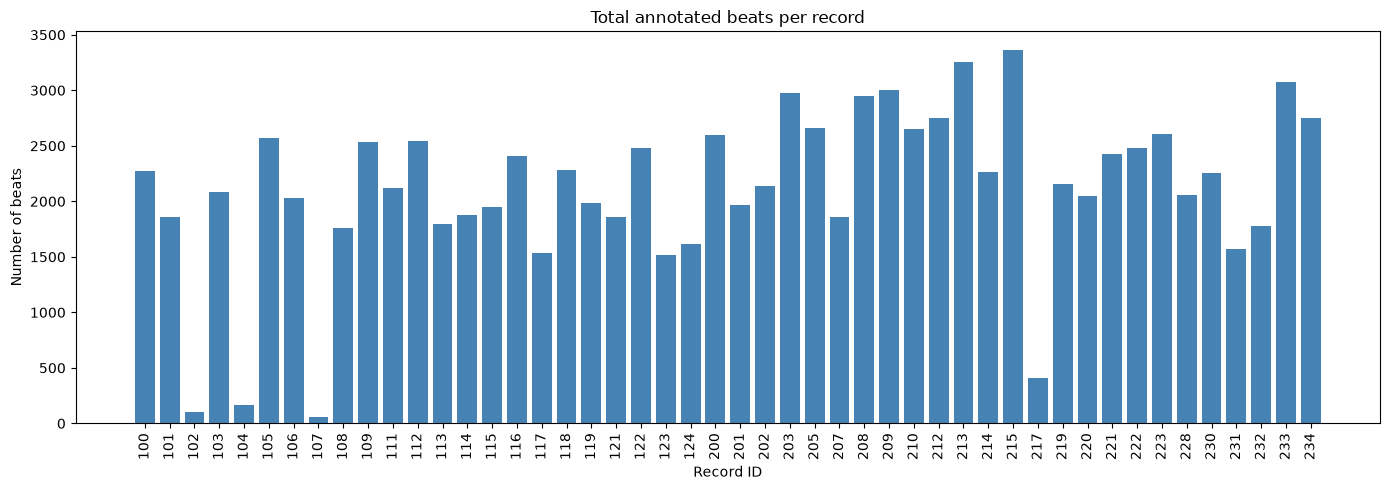

In [24]:
# Count beats per record, broken down by AAMI class
record_class_counts = []

for rec_id in records:
    ann = wfdb.rdann(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}', 'atr')
    counts = {'N': 0, 'S': 0, 'V': 0, 'F': 0}
    for sym in ann.symbol:
        if sym in aami_map:
            counts[aami_map[sym]] += 1
    counts['record'] = rec_id
    counts['total'] = sum(counts[c] for c in ['N', 'S', 'V', 'F'])
    record_class_counts.append(counts)

df_per_record = pd.DataFrame(record_class_counts)
df_per_record = df_per_record[['record', 'N', 'S', 'V', 'F', 'total']]

print(df_per_record.to_string(index=False))

# Plot total beats per record
plt.figure(figsize=(14, 5))
plt.bar(df_per_record['record'], df_per_record['total'], color='steelblue')
plt.xticks(rotation=90)
plt.title('Total annotated beats per record')
plt.xlabel('Record ID')
plt.ylabel('Number of beats')
plt.tight_layout()
plt.show()

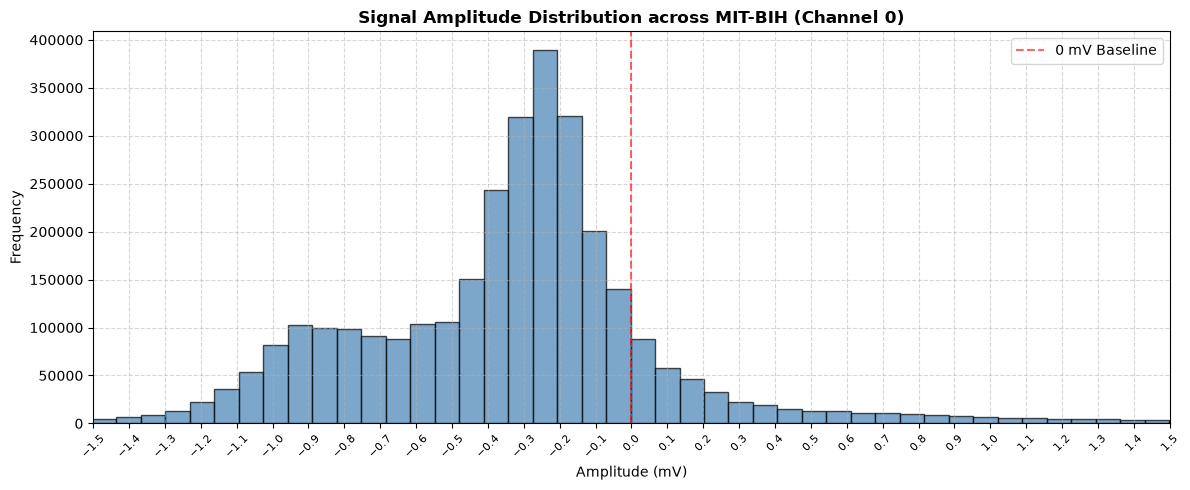

In [28]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

records = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

# Sample a subset of signals to efficiently compute amplitude distribution
sampled_amplitudes = []
for rec_id in records:
    rec = wfdb.rdrecord(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}')
    # Take channel 0 and sample every 10th point to optimize memory
    sampled_amplitudes.extend(rec.p_signal[::10, 0])

plt.figure(figsize=(12, 5))

# Plot histogram with fine bin resolution
counts, bins, patches = plt.hist(sampled_amplitudes, bins=150, color='steelblue', edgecolor='black', alpha=0.7)

# Identify the peak bin position
max_bin_idx = np.argmax(counts)
peak_val = (bins[max_bin_idx] + bins[max_bin_idx + 1]) / 2

# Set zoomed-in view and high-density x-ticks (every 0.1 mV)
plt.xlim(-1.5, 1.5)
plt.xticks(np.arange(-1.5, 1.6, 0.1), rotation=45, fontsize=8)

# Reference lines
plt.axvline(0, color='red', linestyle='--', alpha=0.6, label='0 mV Baseline')

plt.title('Signal Amplitude Distribution across MIT-BIH (Channel 0)', fontsize=12, fontweight='bold')
plt.xlabel('Amplitude (mV)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

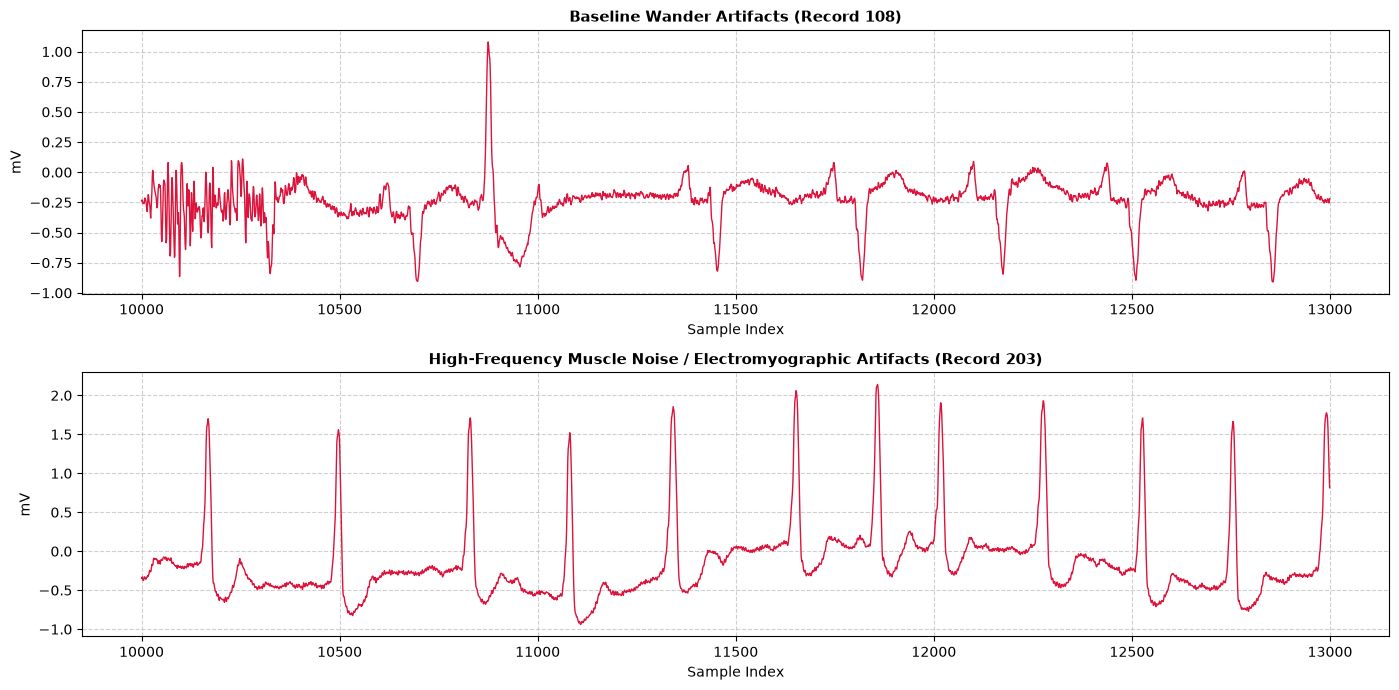

In [30]:
import wfdb
import matplotlib.pyplot as plt

# Selected records with optimal time windows for high-contrast noise visualization
noise_records = [
    {'rec': '108', 'title': 'Baseline Wander Artifacts (Record 108)', 'start': 10000, 'end': 13000},
    {'rec': '203', 'title': 'High-Frequency Muscle Noise / Electromyographic Artifacts (Record 203)', 'start': 10000, 'end': 13000}
]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for idx, item in enumerate(noise_records):
    rec_id = item['rec']
    start_p, end_p = item['start'], item['end']
    
    # Read signal segment
    record = wfdb.rdrecord(f'../data/mit-bih-arrhythmia-database-1.0.0/{rec_id}')
    signal_segment = record.p_signal[start_p:end_p, 0]
    time_axis = range(start_p, end_p)
    
    # Plot noisy signal segment
    axes[idx].plot(time_axis, signal_segment, color='crimson', linewidth=1)
    axes[idx].set_title(item['title'], fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Sample Index")
    axes[idx].set_ylabel("mV")
    axes[idx].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()